In [1]:
from visualize_utils import *

In [2]:
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import json 
import os 
import glob

# Extract tracer type from filename
def get_tracer_type(filename):
    """Extract tracer type (FDG or PSMA) from filename"""
    if 'target' in filename.lower():
        return 'PSMA'
    if 'fdg' in filename.lower():
        return 'FDG'
    elif 'psma' in filename.lower():
        return 'PSMA'
    else:
        return 'PSMA'
import pandas as pd
SPLIT_JSON = '/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_processed/Dataset999_AutoPet/splits_final.json'

with open(SPLIT_JSON, 'r') as f:
    splits = json.load(f)

with open('datasets_111_splits.json', 'r') as f:
    dataset_111_splits = json.load(f)

autopet_embedding_df = pd.read_csv("embedding_normalized__niigz_metadata.csv")
import pickle 

with open("embeddings_normalized__niigz_.pkl", "rb") as f: # AutoPET embeddings
    class_embeddings = pickle.load(f)

    
# with open("dhmc_w_reports_embeddings.pkl", "rb") as f: #DH Embeddings
#     dh_class_embeddings = pickle.load(f)

# with open("dhmc_resampled_embeddings.pkl", "rb") as f:
#      dh_class_embeddings = pickle.load(f)


# dh_class_embeddings['filename'] = dh_class_embeddings['filename'].apply(lambda x: x.replace('_0001.nii.gz', ''))
# unlabelled_class_embeddings = dh_class_embeddings

LABELLED_SPLIT = 5

class_embeddings['filename'] = class_embeddings['filename'].apply(lambda x: x.replace('_0001.nii.gz', ''))  # Remove .nii.gz extension for matching
labelled_class_embeddings = class_embeddings.loc[class_embeddings['filename'].replace('_0001.nii.gz', '').isin(dataset_111_splits[LABELLED_SPLIT]['train'])]
unlabelled_class_embeddings = class_embeddings.loc[~class_embeddings['filename'].replace('_0001.nii.gz', '').isin(dataset_111_splits[LABELLED_SPLIT]['train'])]



In [3]:

def prep_embeddings(subset_class_embeddings):
    return np.array([np.array(e) for e in subset_class_embeddings['cls'].values]), subset_class_embeddings['filename'].values

# Prepare labelled embeddings with tracer info
labelled_cls, labelled_files = prep_embeddings(labelled_class_embeddings)
labelled_tracers = np.array([get_tracer_type(f) for f in labelled_files])

# make the unlablled embeddings the dh ones 
unlabelled_cls, unlabelled_files = prep_embeddings(unlabelled_class_embeddings)
unlabelled_tracers = np.array([get_tracer_type(f) for f in unlabelled_files])

if len(unlabelled_tracers) == 0:
    print("No unlabelled tracers found.")
    unlabelled_tracers = np.array(['PSMA'] * len(unlabelled_files))

print(len(labelled_files), len(unlabelled_files), len(labelled_tracers), len(unlabelled_tracers))


417 626 417 626


In [4]:
from sklearn.decomposition import KernelPCA

print("=" * 80)
print("LABELLED DATA ANALYSIS")
print("=" * 80)
print(f"Total labelled samples: {len(labelled_cls)}")
print(f"  FDG: {sum(labelled_tracers == 'FDG')}")
print(f"  PSMA: {sum(labelled_tracers == 'PSMA')}")

print("\n" + "=" * 80)
print("UNLABELLED DATA ANALYSIS")
print("=" * 80)
print(f"Total unlabelled samples: {len(unlabelled_cls)}")
print(f"  FDG: {sum(unlabelled_tracers == 'FDG')}")
print(f"  PSMA: {sum(unlabelled_tracers == 'PSMA')}")

labelled_results = {}
for tracer in ['FDG', 'PSMA']:
    tracer_mask = labelled_tracers == tracer
    tracer_embeddings = labelled_cls[tracer_mask]
    tracer_files = labelled_files[tracer_mask]

    print(f"\n--- {tracer} (n={len(tracer_embeddings)}) ---")
    kpca = KernelPCA(n_components=2, kernel='cosine')
    tracer_kpca = kpca.fit_transform(tracer_embeddings)  # fit on labelled only
    stats = compute_pairwise_cosine_stats(tracer_embeddings, tracer_files)

    labelled_results[tracer] = {
        'kpca': kpca,           # save fitted kpca to reuse for unlabelled
        'kpca_coords': tracer_kpca,
        'embeddings': tracer_embeddings,
        'files': tracer_files,
        'pairwise_distances': stats['pairwise_distances'],
        'closest': stats['closest'],
        'furthest': stats['furthest'],
    }


unlabelled_results = {}
for tracer in ['FDG', 'PSMA', 'DHMC']:
    tracer_mask_u = unlabelled_tracers == tracer
    tracer_embeddings_u = unlabelled_cls[tracer_mask_u]
    tracer_files_u = unlabelled_files[tracer_mask_u]

    tracer_mask_l = labelled_tracers == tracer
    tracer_embeddings_l = labelled_cls[tracer_mask_l]
    tracer_files_l = labelled_files[tracer_mask_l]

    if len(tracer_embeddings_u) < 2:
        print(f"\n{tracer}: Only {len(tracer_embeddings_u)} unlabelled samples, skipping...")
        continue

    print(f"\n--- {tracer} (unlabelled n={len(tracer_embeddings_u)}, labelled n={len(tracer_embeddings_l)}) ---")
    
    if len(tracer_embeddings_l) > 0:
        # Reuse the kpca already fitted on labelled data — do NOT refit
        kpca = labelled_results[tracer]['kpca']
        labelled_kpca = labelled_results[tracer]['kpca_coords']   # already computed
        unlabelled_kpca = kpca.transform(tracer_embeddings_u)     # just project
    else:
        # No labelled data for this tracer, fit fresh on unlabelled only
        kpca = KernelPCA(n_components=2, kernel='cosine')
        unlabelled_kpca = kpca.fit_transform(tracer_embeddings_u)
        labelled_kpca = np.empty((0, 2))

    print(f"  Kernel PCA (cosine) fitted on labelled data — unlabelled projected in")

    # Distances computed in original embedding space (unchanged)
    stats_u = compute_pairwise_cosine_stats(tracer_embeddings_u, tracer_files_u)

    min_dist_to_labelled = compute_unlabelled_distance_to_labelled(tracer_embeddings_u, tracer_embeddings_l)
    k_far = min(5, len(tracer_embeddings_u))
    far_from_labelled_idx = np.argsort(min_dist_to_labelled)[-k_far:][::-1]
    for rank, fi in enumerate(far_from_labelled_idx):
        print(f"    #{rank+1} cosine_dist={min_dist_to_labelled[fi]:.6f}  {tracer_files_u[fi]}")

    unlabelled_results[tracer] = {
        'kpca': kpca,
        'kpca_coords_unlabelled': unlabelled_kpca,
        'kpca_coords_labelled': labelled_kpca,
        'embeddings_unlabelled': tracer_embeddings_u,
        'embeddings_labelled': tracer_embeddings_l,
        'files_unlabelled': tracer_files_u,
        'files_labelled': tracer_files_l,
        'pairwise_distances_uu': stats_u['pairwise_distances'],
        'min_dist_to_labelled': min_dist_to_labelled,
        'far_from_labelled_idx': far_from_labelled_idx,
        'closest': stats_u['closest'],
        'furthest': stats_u['furthest'],
    }
    from sklearn.metrics.pairwise import cosine_distances

    D = cosine_distances(tracer_embeddings_u, tracer_embeddings_l)  # (n_u, n_l)
    u_idx, l_idx = np.unravel_index(np.argmin(D), D.shape)



LABELLED DATA ANALYSIS
Total labelled samples: 417
  FDG: 266
  PSMA: 151

UNLABELLED DATA ANALYSIS
Total unlabelled samples: 626
  FDG: 398
  PSMA: 228

--- FDG (n=266) ---

--- PSMA (n=151) ---

--- FDG (unlabelled n=398, labelled n=266) ---
  Kernel PCA (cosine) fitted on labelled data — unlabelled projected in
    #1 cosine_dist=0.106788  fdg_ae96f738c0_09-11-2003-NA-PET-CT Ganzkoerper  primaer mit KM-60169
    #2 cosine_dist=0.106095  fdg_a19ef8e0d2_12-26-1999-NA-PET-CT Ganzkoerper  primaer mit KM-80792
    #3 cosine_dist=0.105650  fdg_8311aeddb9_12-16-2005-NA-PET-CT Ganzkoerper  primaer mit KM-57155
    #4 cosine_dist=0.105112  fdg_8c5d99b459_05-04-2007-NA-PET-CT Ganzkoerper  primaer mit KM-16657
    #5 cosine_dist=0.104506  fdg_ddca6cfba6_02-27-2004-NA-PET-CT Ganzkoerper  primaer mit KM-47148

--- PSMA (unlabelled n=228, labelled n=151) ---
  Kernel PCA (cosine) fitted on labelled data — unlabelled projected in
    #1 cosine_dist=0.118656  psma_838c9340e85ca431_2015-09-11
    #2

In [5]:
tracer = 'PSMA'   # or 'PSMA'
r = unlabelled_results[tracer]
emb_u = r['embeddings_unlabelled']
emb_l = r['embeddings_labelled']
files_u = r['files_unlabelled']
files_l = r['files_labelled']

D = cosine_distances(emb_u, emb_l)          # (n_u, n_l)
u_idx, l_idx = np.unravel_index(np.argmin(D), D.shape)

print(f"  {tracer} closest unlabelled↔labelled: cosine_dist={D[u_idx, l_idx]:.6f}")
print(f"    unlabelled file: {files_u[u_idx]}")
print(f"    labelled file:   {files_l[l_idx]}")


# furthest unlabelled↔labelled
print("\n" + "=" * 80)
print(f"  {tracer} furthest unlabelled↔labelled: cosine_dist={D.max():.6f}")
u_idx, l_idx = np.unravel_index(np.argmax(D), D.shape)
print(f"    unlabelled file: {files_u[u_idx]}")
print(f"    labelled file:   {files_l[l_idx]}")

  PSMA closest unlabelled↔labelled: cosine_dist=0.043333
    unlabelled file: psma_1122a9de80627036_2017-11-13
    labelled file:   psma_ede705184679888a_2017-02-26

  PSMA furthest unlabelled↔labelled: cosine_dist=0.538241
    unlabelled file: psma_19eed20451e33bc1_2019-09-23
    labelled file:   psma_bc70d4dbddba497e_2020-09-25


In [6]:
tracer = 'FDG'   # or 'PSMA'
r = unlabelled_results[tracer]
emb_u = r['embeddings_unlabelled']
emb_l = r['embeddings_labelled']
files_u = r['files_unlabelled']
files_l = r['files_labelled']

D = cosine_distances(emb_u, emb_l)          # (n_u, n_l)
u_idx, l_idx = np.unravel_index(np.argmin(D), D.shape)

print(f"  {tracer} closest unlabelled↔labelled: cosine_dist={D[u_idx, l_idx]:.6f}")
print(f"    unlabelled file: {files_u[u_idx]}")
print(f"    labelled file:   {files_l[l_idx]}")


# furthest unlabelled↔labelled
print("\n" + "=" * 80)
print(f"  {tracer} furthest unlabelled↔labelled: cosine_dist={D.max():.6f}")
u_idx, l_idx = np.unravel_index(np.argmax(D), D.shape)
print(f"    unlabelled file: {files_u[u_idx]}")
print(f"    labelled file:   {files_l[l_idx]}")

  FDG closest unlabelled↔labelled: cosine_dist=0.036244
    unlabelled file: fdg_147a9fcff3_08-16-2001-NA-PET-CT Ganzkoerper  primaer mit KM-80653
    labelled file:   fdg_544676de40_03-23-2007-NA-PET-CT Ganzkoerper  primaer mit KM-57333

  FDG furthest unlabelled↔labelled: cosine_dist=0.582109
    unlabelled file: fdg_9b9d67b3ff_07-12-2003-NA-PET-CT Teilkoerper  primaer mit KM-95263
    labelled file:   fdg_39eca178a1_06-08-2003-NA-PET-CT Ganzkoerper  primaer mit KM-91097


In [7]:
# in the labelled and unlabelled files, are there any overlap in type? 
for tracer in ['fdg']:
    labelled_files_tracer = set(labelled_class_embeddings[labelled_class_embeddings['filename'].str.contains(tracer)]['filename'])
    unlabelled_files_tracer = set(unlabelled_class_embeddings[unlabelled_class_embeddings['filename'].str.contains(tracer)]['filename'])
    overlap = labelled_files_tracer.intersection(unlabelled_files_tracer)
    print(f"Overlap for {tracer}: {len(overlap)} files")
    


Overlap for fdg: 0 files


Processing tracer: PSMA with 228 unlabelled samples
Processing tracer: FDG with 398 unlabelled samples

TOP 10.0% FURTHEST IMAGES BY TRACER

FDG (n=67)
tracer                                                              filename  dist_to_labelled  index
   FDG fdg_ae96f738c0_09-11-2003-NA-PET-CT Ganzkoerper  primaer mit KM-60169          0.106788     80
   FDG fdg_a19ef8e0d2_12-26-1999-NA-PET-CT Ganzkoerper  primaer mit KM-80792          0.106095    103
   FDG fdg_8311aeddb9_12-16-2005-NA-PET-CT Ganzkoerper  primaer mit KM-57155          0.105650    269
   FDG fdg_8c5d99b459_05-04-2007-NA-PET-CT Ganzkoerper  primaer mit KM-16657          0.105112    321
   FDG fdg_ddca6cfba6_02-27-2004-NA-PET-CT Ganzkoerper  primaer mit KM-47148          0.104506    249
   FDG           fdg_f8314eb3f7_09-20-2003-NA-PET-CT Ganzkoerper nativ-98309          0.104095    291
   FDG fdg_89065bc4ab_02-20-2004-NA-PET-CT Ganzkoerper  primaer mit KM-11843          0.104079    396
   FDG fdg_06d55e8295_04-17-2003

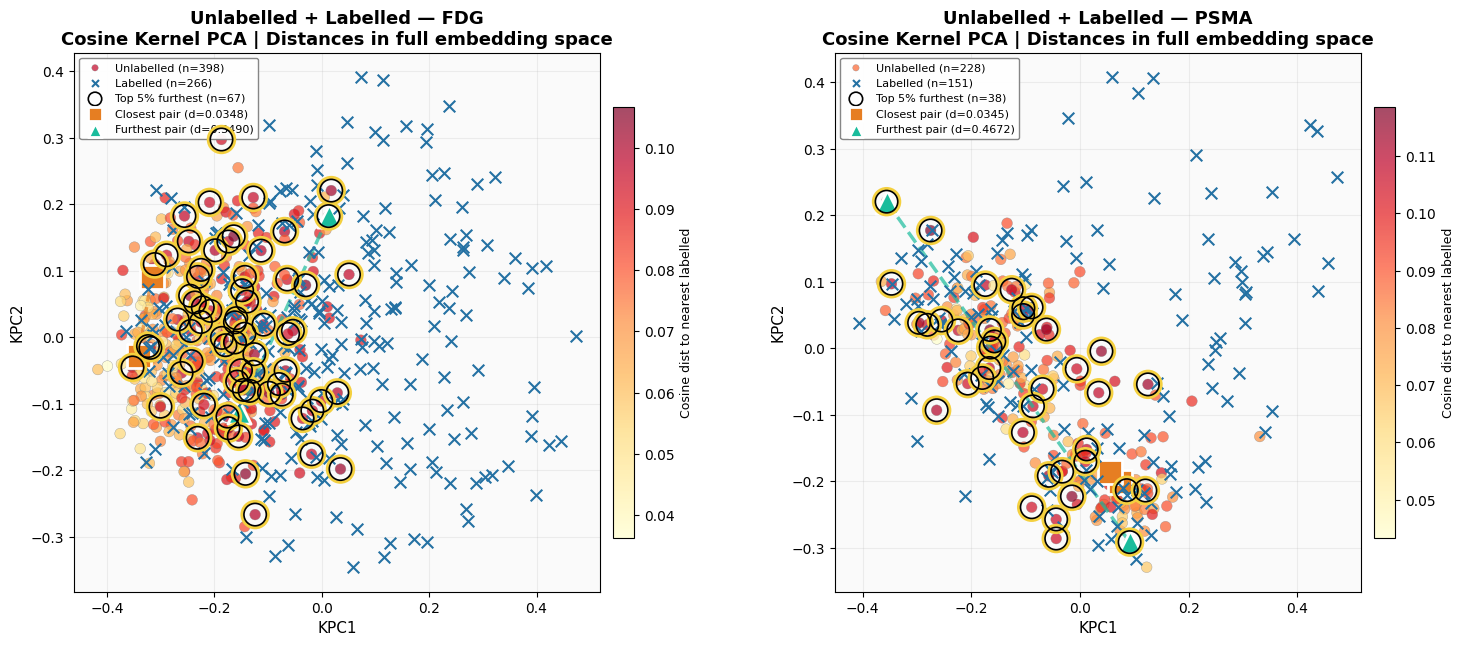

In [17]:

distance_df = build_distance_dataframe(unlabelled_results)


TOP_PERCENT = 0.1
# Tracer-aware top 5% selection
top_5_df = get_top_percent_farthest_by_tracer(distance_df, top_percent=TOP_PERCENT)
ranked_top_5_df = rank_top_subset_by_diversity(unlabelled_results, top_5_df)

print(f"\n{'='*80}")
print(f"TOP {TOP_PERCENT*100}% FURTHEST IMAGES BY TRACER")
print(f"{'='*80}")
for tracer in ['FDG', 'PSMA', 'DHMC']:
    tracer_top5 = top_5_df[top_5_df['tracer'] == tracer]
    print(f"\n{tracer} (n={len(tracer_top5)})")
    if tracer_top5.empty:
        print("  No samples found.")
    else:
        print(tracer_top5.to_string(index=False))

print(f"\n{'='*80}")
print("TOP 5% RANKED BY DIVERSITY WITHIN THAT SUBSET")
print(f"{'='*80}")
print(ranked_top_5_df.to_string(index=False))

fig, ax = plot_kernel_pca_with_top_subset(unlabelled_results, labelled_results, top_5_df)

print("\n" + "=" * 80)
print("SUMMARY FOR FILE SELECTION")
print("=" * 80)

for tracer in ['FDG', 'PSMA']:
    if tracer in labelled_results:
        furthest = labelled_results[tracer]['furthest']
        print(f"\nLABELLED {tracer} most diverse pair:")
        print(f"  {furthest[2]}")
        print(f"  {furthest[3]}")

for tracer in ['FDG', 'PSMA']:
    if tracer in unlabelled_results:
        closest = unlabelled_results[tracer]['closest']
        print(f"\nUNLABELLED {tracer} most redundant pair:")
        print(f"  {closest[2]}")
        print(f"  {closest[3]}")

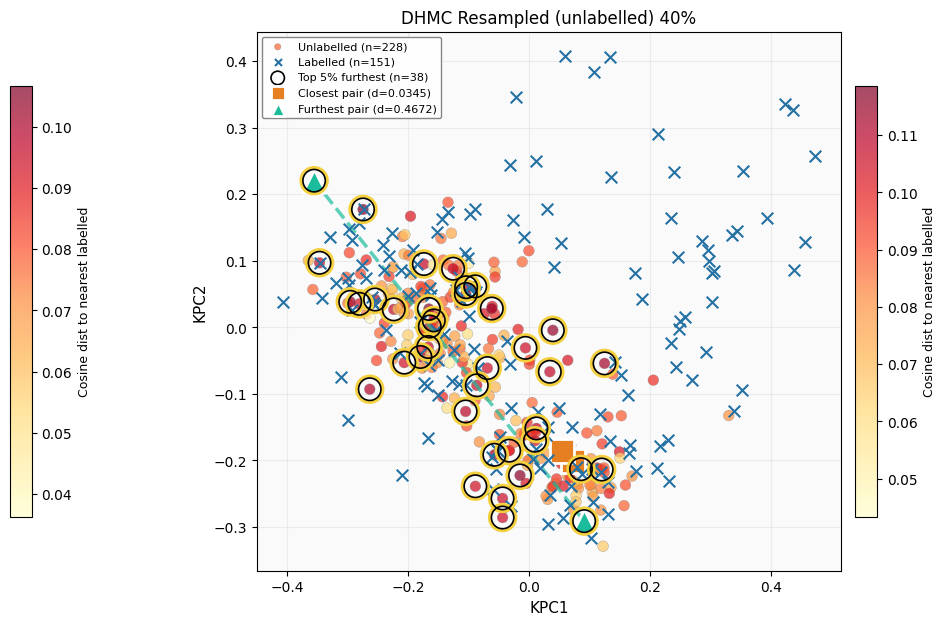

In [18]:
fig, axes = plot_kernel_pca_with_top_subset(unlabelled_results, labelled_results, top_5_df)

axes[0].remove()  # remove empty first subplot

fig.set_size_inches(20, 7)  # make figure smaller
axes[1].set_title("DHMC Resampled (unlabelled) 40%")
plt.show()

In [19]:
unlabelled_results['FDG']['furthest']

((np.int64(197), np.int64(396)),
 np.float64(0.3489774304163191),
 'fdg_48d5467561_10-28-2005-NA-PET-CT Ganzkoerper  primaer mit KM-70383',
 'fdg_89065bc4ab_02-20-2004-NA-PET-CT Ganzkoerper  primaer mit KM-11843')

In [20]:
unlabelled_results['FDG']['closest']

((np.int64(36), np.int64(236)),
 np.float64(0.03480119718619901),
 'fdg_5e339b2ecf_11-11-2005-NA-PET-CT Ganzkoerper  primaer mit KM-39829',
 'fdg_5e339b2ecf_05-27-2006-NA-PET-CT Ganzkoerper  primaer mit KM-41089')

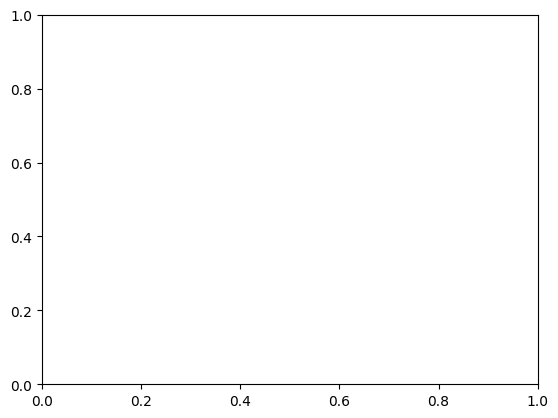

In [21]:
import matplotlib.pyplot as plt

# Create new figure
new_fig, new_ax = plt.subplots()

# Copy the second subplot into new figure
new_ax = ax[1]  

fig2 = new_ax.get_figure()

In [22]:
fig

# only show the second subfig
ax

array([<Axes: title={'center': 'Unlabelled + Labelled — FDG\nCosine Kernel PCA | Distances in full embedding space'}, xlabel='KPC1', ylabel='KPC2'>,
       <Axes: title={'center': 'Unlabelled + Labelled — PSMA\nCosine Kernel PCA | Distances in full embedding space'}, xlabel='KPC1', ylabel='KPC2'>],
      dtype=object)

In [23]:
SAVE_DIR = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_0_10/train_tta_predicted_bad_subset/'

csv_files = glob.glob(os.path.join(SAVE_DIR, '*fixed*.csv'))
print(len(csv_files))
combined_df = pd.read_csv(csv_files[0])
summary_stats_df = pd.read_csv(csv_files[0])
uncertainty_df = pd.read_csv(csv_files[1])
summary_stats_df['filename'] = summary_stats_df['filename'].str.replace('.nii.gz', '', regex=False)


2


In [24]:
def plot_kernel_pca_unc_with_top_subset(unlabelled_results, labelled_results, top_subset_df, summary_stats_df):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    summary_stats_df = summary_stats_df.copy()
    summary_stats_df['filename'] = summary_stats_df['filename'].str.replace('.nii.gz', '', regex=False)
    summary_stats_df = summary_stats_df.set_index('filename')

    for idx, tracer in enumerate(['FDG', 'PSMA']):
        if tracer not in unlabelled_results:
            continue

        result = unlabelled_results[tracer]
        u_pca = result['kpca_coords_unlabelled']
        l_pca = result['kpca_coords_labelled']
        closest_idx = result['closest'][0]
        furthest_idx = result['furthest'][0]
        ax = axes[idx]

        tracer_top = top_subset_df[top_subset_df['tracer'] == tracer]
        tracer_top_n = len(tracer_top)

        u_files = result['files_unlabelled']
        uncertainty = np.array([
            summary_stats_df['average_uncertainty_predicted'].get(f, np.nan) for f in u_files
        ])
        uncertainty_log = (uncertainty)

        scatter = ax.scatter(
            u_pca[:, 0], u_pca[:, 1],
            c=uncertainty_log, cmap='YlOrRd', s=60,
            edgecolors='gray', linewidth=0.3, alpha=0.7,
            label=f'Unlabelled (n={len(u_pca)})', zorder=2
        )
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.8, pad=0.02)
        cbar.set_label('log1p(uncertainty)', fontsize=9)

        ax.scatter(l_pca[:, 0], l_pca[:, 1],
                   c='#2471A3', s=70, marker='x', alpha=1.0,
                   label=f'Labelled (n={len(l_pca)})', zorder=10)

        if not tracer_top.empty:
            top_idx = tracer_top['index'].to_numpy()
            ax.scatter(u_pca[top_idx, 0], u_pca[top_idx, 1],
                       facecolors='none', s=260, marker='o', edgecolors='black', linewidth=1.2,
                       label=f'Top 5% furthest (n={tracer_top_n})', zorder=11)
            ax.scatter(u_pca[top_idx, 0], u_pca[top_idx, 1],
                       facecolors='none', s=360, marker='o', edgecolors='#F4D03F', linewidth=2.2,
                       zorder=10)

        ax.scatter(u_pca[closest_idx[0], 0], u_pca[closest_idx[0], 1],
                   color='#E67E22', s=280, marker='s', edgecolors='white', linewidth=2, zorder=8)
        ax.scatter(u_pca[closest_idx[1], 0], u_pca[closest_idx[1], 1],
                   color='#E67E22', s=280, marker='s', edgecolors='white', linewidth=2,
                   label=f'Closest pair (d={result["closest"][1]:.4f})', zorder=8)
        ax.plot([u_pca[closest_idx[0], 0], u_pca[closest_idx[1], 0]],
                [u_pca[closest_idx[0], 1], u_pca[closest_idx[1], 1]],
                color='#E67E22', linestyle='--', linewidth=2.5, alpha=0.7, zorder=3)

        ax.scatter(u_pca[furthest_idx[0], 0], u_pca[furthest_idx[0], 1],
                   color='#1ABC9C', s=280, marker='^', edgecolors='white', linewidth=2, zorder=8)
        ax.scatter(u_pca[furthest_idx[1], 0], u_pca[furthest_idx[1], 1],
                   color='#1ABC9C', s=280, marker='^', edgecolors='white', linewidth=2,
                   label=f'Furthest pair (d={result["furthest"][1]:.4f})', zorder=8)
        ax.plot([u_pca[furthest_idx[0], 0], u_pca[furthest_idx[1], 0]],
                [u_pca[furthest_idx[0], 1], u_pca[furthest_idx[1], 1]],
                color='#1ABC9C', linestyle='--', linewidth=2.5, alpha=0.7, zorder=3)

        ax.set_xlabel('KPC1', fontsize=11)
        ax.set_ylabel('KPC2', fontsize=11)
        ax.set_title(f'Unlabelled + Labelled — {tracer}\nCosine Kernel PCA | Distances in full embedding space',
                     fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=8, framealpha=0.95, markerscale=0.6,
                  edgecolor='gray', fancybox=True)
        ax.grid(True, alpha=0.2, linestyle='-')
        ax.set_facecolor('#FAFAFA')

    plt.tight_layout()
    plt.show()


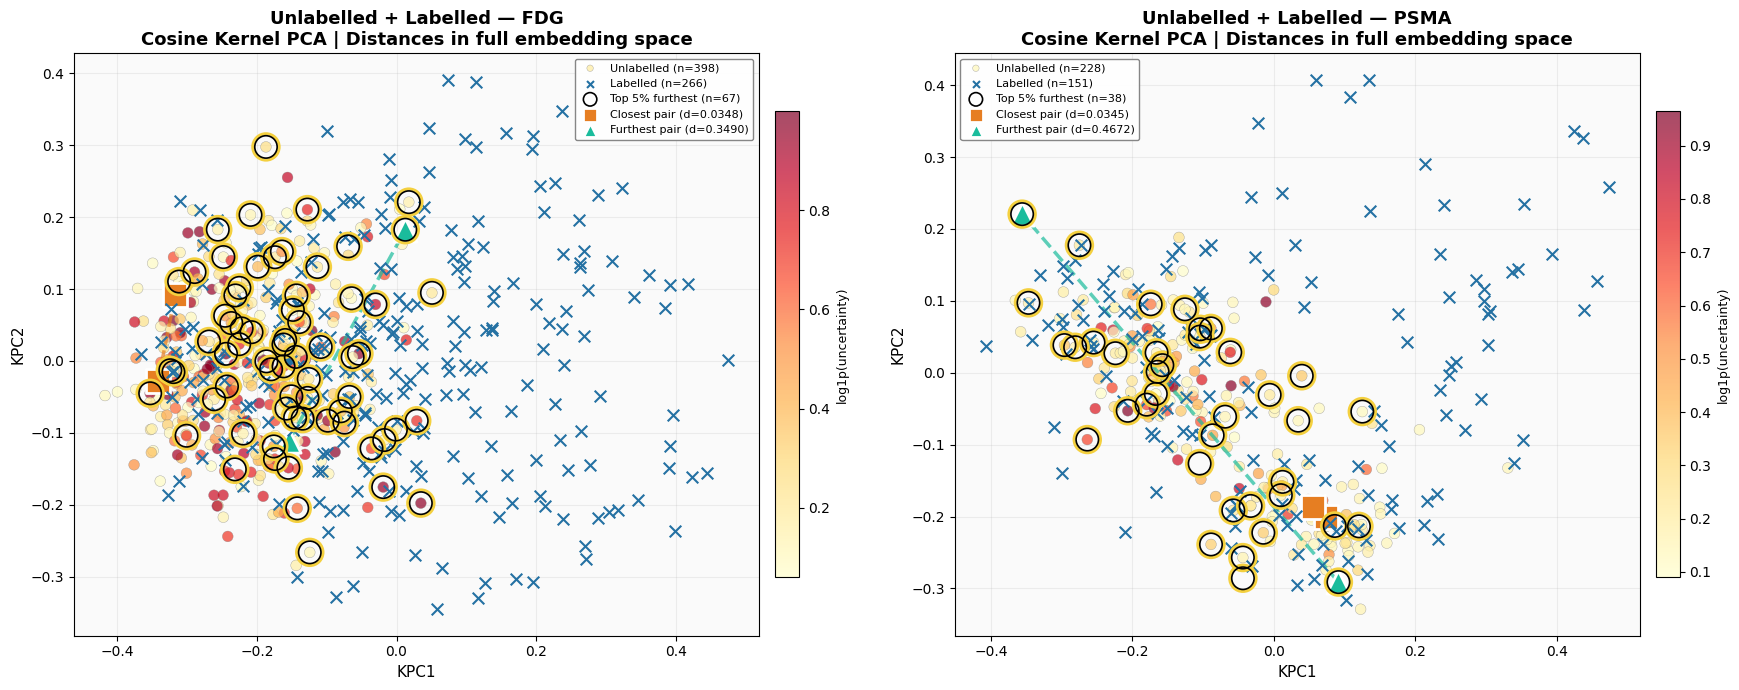

In [25]:
plot_kernel_pca_unc_with_top_subset(unlabelled_results, labelled_results, top_5_df, summary_stats_df)


## Feature-embedding interpretability: neighbours & farthest cases

Supporting the Results (feature-embedding interpretability) section. Everything below is
stratified by tracer and computed in the original embedding space using cosine distance,
matching the rest of this notebook.

The **fixed 10% seed** is Fold 0 of Dataset111 (`dataset_111_splits[0]['train']`), which is
held constant across every dataset. We treat that seed as the *reference pool* and ask what
the unlabelled cases nearest / farthest from it look like, then quantify how much diversity
FEEDS' selected 1% and 5% additions bring on top of that pool.


### Setup: fixed 10% seed pool + shared helpers

We rebuild embedding matrices keyed to the Fold-0 seed rather than the Fold-5 `labelled`
set used earlier, so the "distance-to-pool" numbers below are anchored to the 10% seed the
reviewer referred to. Helpers are self-contained so this block can be run independently of
the earlier cells (it only needs `class_embeddings`, `dataset_111_splits`, `get_tracer_type`,
and `top_5_df` from above).

In [26]:
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
import pandas as pd

TRACERS = ['FDG', 'PSMA']

# ---- Fixed 10% seed = Fold 0 of Dataset111 (constant across all datasets) --------------
SEED_FOLD = 0
seed_ids = set(dataset_111_splits[SEED_FOLD]['train'])

_all_files = class_embeddings['filename'].values
_all_cls   = np.array([np.array(e) for e in class_embeddings['cls'].values])
_all_trac  = np.array([get_tracer_type(f) for f in _all_files])
_in_seed   = np.array([f in seed_ids for f in _all_files])

# Per-tracer views: seed (fixed 10%) vs. the rest (candidate pool)
seed_data, rest_data = {}, {}
for t in TRACERS:
    m = _all_trac == t
    seed_data[t] = {
        'emb':   _all_cls[m &  _in_seed],
        'files': _all_files[m &  _in_seed],
    }
    rest_data[t] = {
        'emb':   _all_cls[m & ~_in_seed],
        'files': _all_files[m & ~_in_seed],
    }
    print(f"{t}: seed(10%) n={len(seed_data[t]['files'])}  |  rest n={len(rest_data[t]['files'])}")


def closest_furthest_within(emb, files):
    """Closest and furthest *pair* inside one set (cosine)."""
    D = cosine_distances(emb, emb)
    np.fill_diagonal(D, np.nan)
    ci, cj = np.unravel_index(np.nanargmin(D), D.shape)
    fi, fj = np.unravel_index(np.nanargmax(D), D.shape)
    return {
        'closest':  (D[ci, cj], files[ci], files[cj]),
        'furthest': (D[fi, fj], files[fi], files[fj]),
    }


def closest_furthest_between(emb_a, files_a, emb_b, files_b):
    """Closest and furthest cross pair between set A and set B (cosine)."""
    D = cosine_distances(emb_a, emb_b)          # (nA, nB)
    ai, bi = np.unravel_index(np.argmin(D), D.shape)
    aj, bj = np.unravel_index(np.argmax(D), D.shape)
    return {
        'closest':  (D[ai, bi], files_a[ai], files_b[bi]),
        'furthest': (D[aj, bj], files_a[aj], files_b[bj]),
    }


FDG: seed(10%) n=66  |  rest n=598
PSMA: seed(10%) n=37  |  rest n=342


### 1. Closest and farthest pairs in the entire feature space (per tracer)

All cases for the tracer (seed + rest), pairwise. The closest pairs are expected to be
near-duplicates — often longitudinal scans of the same patient — while the farthest pairs
mark the extremes of the tracer's manifold.

In [27]:
print("=" * 80)
print("1. CLOSEST / FARTHEST PAIRS — ENTIRE FEATURE SPACE (per tracer)")
print("=" * 80)

space1_rows = []
for t in TRACERS:
    m = _all_trac == t
    emb, files = _all_cls[m], _all_files[m]
    res = closest_furthest_within(emb, files)

    cd, ca, cb = res['closest']
    fd, fa, fb = res['furthest']
    print(f"\n--- {t} (n={len(files)}) ---")
    print(f"  CLOSEST  pair  cosine={cd:.6f}")
    print(f"    {ca}")
    print(f"    {cb}")
    print(f"  FARTHEST pair  cosine={fd:.6f}")
    print(f"    {fa}")
    print(f"    {fb}")

    space1_rows += [
        {'tracer': t, 'relation': 'closest',  'cosine': cd, 'case_a': ca, 'case_b': cb},
        {'tracer': t, 'relation': 'furthest', 'cosine': fd, 'case_a': fa, 'case_b': fb},
    ]

entire_space_pairs_df = pd.DataFrame(space1_rows)
entire_space_pairs_df


1. CLOSEST / FARTHEST PAIRS — ENTIRE FEATURE SPACE (per tracer)

--- FDG (n=664) ---
  CLOSEST  pair  cosine=0.034801
    fdg_5e339b2ecf_11-11-2005-NA-PET-CT Ganzkoerper  primaer mit KM-39829
    fdg_5e339b2ecf_05-27-2006-NA-PET-CT Ganzkoerper  primaer mit KM-41089
  FARTHEST pair  cosine=0.582512
    fdg_39eca178a1_06-08-2003-NA-PET-CT Ganzkoerper  primaer mit KM-91097
    fdg_52f84711a5_04-01-2006-NA-PET-CT Teilkoerper  primaer mit KM-59163

--- PSMA (n=379) ---
  CLOSEST  pair  cosine=0.034525
    psma_798b3279d6980a3b_2018-11-19
    psma_798b3279d6980a3b_2019-05-31
  FARTHEST pair  cosine=0.616144
    psma_790ee2c577d4ceed_2021-02-15
    psma_35852148926fc57d_2018-03-23


,tracer,relation,cosine,case_a,case_b
0,FDG,closest,0.034801,fdg_5e339b2ecf_11-11-2005-NA-PET-CT Ganzkoerpe...,fdg_5e339b2ecf_05-27-2006-NA-PET-CT Ganzkoerpe...
1,FDG,furthest,0.582512,fdg_39eca178a1_06-08-2003-NA-PET-CT Ganzkoerpe...,fdg_52f84711a5_04-01-2006-NA-PET-CT Teilkoerpe...
2,PSMA,closest,0.034525,psma_798b3279d6980a3b_2018-11-19,psma_798b3279d6980a3b_2019-05-31
3,PSMA,furthest,0.616144,psma_790ee2c577d4ceed_2021-02-15,psma_35852148926fc57d_2018-03-23


### 2. Unlabelled → fixed 10% seed: closest and farthest pairs (per tracer)

Cross distances between each candidate (non-seed) case and the fixed 10% seed pool.

- **Closest** cross pair → the candidate best represented by the seed (redundant to add).
- **Farthest** cross pair → the candidate the seed represents *worst*.

We also list the top-5 candidates by *distance to nearest seed case* — these are the
regions the 10% seed under-covers, i.e. exactly where FEEDS should be pulling from if it is
picking up diversity.

In [28]:
print("=" * 80)
print("2. UNLABELLED (rest) -> FIXED 10% SEED  (per tracer)")
print("=" * 80)

unl_to_seed_rows = []
for t in TRACERS:
    emb_u, files_u = rest_data[t]['emb'], rest_data[t]['files']
    emb_s, files_s = seed_data[t]['emb'], seed_data[t]['files']

    res = closest_furthest_between(emb_u, files_u, emb_s, files_s)
    cd, cu, cs = res['closest']
    fd, fu, fs = res['furthest']

    print(f"\n--- {t} (unlabelled n={len(files_u)}, seed n={len(files_s)}) ---")
    print(f"  CLOSEST  unlabelled<->seed  cosine={cd:.6f}")
    print(f"    unlabelled: {cu}")
    print(f"    seed:       {cs}")
    print(f"  FARTHEST unlabelled<->seed  cosine={fd:.6f}")
    print(f"    unlabelled: {fu}")
    print(f"    seed:       {fs}")

    # per-candidate distance to NEAREST seed case -> under-covered regions
    D = cosine_distances(emb_u, emb_s)          # (n_u, n_seed)
    min_to_seed = D.min(axis=1)
    order = np.argsort(min_to_seed)[::-1][:5]
    print(f"  Top-5 candidates FARTHEST from the seed (worst-covered):")
    for rank, i in enumerate(order, 1):
        print(f"    #{rank}  min_cos_to_seed={min_to_seed[i]:.6f}  {files_u[i]}")

    unl_to_seed_rows += [
        {'tracer': t, 'relation': 'closest',  'cosine': cd, 'unlabelled': cu, 'seed': cs},
        {'tracer': t, 'relation': 'furthest', 'cosine': fd, 'unlabelled': fu, 'seed': fs},
    ]

unlabelled_to_seed_pairs_df = pd.DataFrame(unl_to_seed_rows)
unlabelled_to_seed_pairs_df


2. UNLABELLED (rest) -> FIXED 10% SEED  (per tracer)

--- FDG (unlabelled n=598, seed n=66) ---
  CLOSEST  unlabelled<->seed  cosine=0.036244
    unlabelled: fdg_147a9fcff3_08-16-2001-NA-PET-CT Ganzkoerper  primaer mit KM-80653
    seed:       fdg_544676de40_03-23-2007-NA-PET-CT Ganzkoerper  primaer mit KM-57333
  FARTHEST unlabelled<->seed  cosine=0.582512
    unlabelled: fdg_39eca178a1_06-08-2003-NA-PET-CT Ganzkoerper  primaer mit KM-91097
    seed:       fdg_52f84711a5_04-01-2006-NA-PET-CT Teilkoerper  primaer mit KM-59163
  Top-5 candidates FARTHEST from the seed (worst-covered):
    #1  min_cos_to_seed=0.299302  fdg_39eca178a1_06-08-2003-NA-PET-CT Ganzkoerper  primaer mit KM-91097
    #2  min_cos_to_seed=0.267789  fdg_d69c3fceba_04-05-2003-NA-PET-CT Ganzkoerper  primaer mit KM-13415
    #3  min_cos_to_seed=0.267604  fdg_1928952a0f_06-20-2003-NA-PET-CT Ganzkoerper  primaer mit KM-40834
    #4  min_cos_to_seed=0.260880  fdg_0f44cec2e6_09-07-2003-NA-PET-CT Ganzkoerper  primaer mit KM

,tracer,relation,cosine,unlabelled,seed
0,FDG,closest,0.036244,fdg_147a9fcff3_08-16-2001-NA-PET-CT Ganzkoerpe...,fdg_544676de40_03-23-2007-NA-PET-CT Ganzkoerpe...
1,FDG,furthest,0.582512,fdg_39eca178a1_06-08-2003-NA-PET-CT Ganzkoerpe...,fdg_52f84711a5_04-01-2006-NA-PET-CT Teilkoerpe...
2,PSMA,closest,0.043333,psma_1122a9de80627036_2017-11-13,psma_ede705184679888a_2017-02-26
3,PSMA,furthest,0.616144,psma_790ee2c577d4ceed_2021-02-15,psma_35852148926fc57d_2018-03-23


In [42]:
# load the leasion metrics file 
lesion_metrics_dir = '//dartfs/rc/lab/B/BhattacharyaI/Results/nnUNet_data/nnUNet_results/Dataset999_AutoPet/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/fold_9/test_predictions/lesion_metrics.csv'
summary_json_dir = lesion_metrics_dir.replace('lesion_metrics.csv', 'summary.json')


lesion_metrics_df = pd.read_csv(lesion_metrics_dir)
# summary_json_df = pd.read_json(summary_json_dir, orient='index').reset_index().rename(columns={'index': 'filename'})
lesion_metrics_df.head(2)


,filename,dice_score,false_pos_vol,false_neg_vol,false_missed_lesions,false_detected_lesions,num_gt_lesions,num_pred_lesions
0,psma_de1f4300eda3bef3_2016-01-31.nii.gz,0.555556,0.000000,0.0,0,0,5,5
1,fdg_a8a5e96821_03-11-2005-NA-PET-CT Ganzkoerpe...,NaN,1.157015,0.0,0,3,0,3


0    fdg_147a9fcff3_08-16-2001-NA-PET-CT Ganzkoerpe...
1    fdg_39eca178a1_06-08-2003-NA-PET-CT Ganzkoerpe...
2                     psma_1122a9de80627036_2017-11-13
3                     psma_790ee2c577d4ceed_2021-02-15
Name: unlabelled, dtype: object

In [65]:
unlabelled_to_seed_pairs_df

,tracer,relation,cosine,unlabelled,seed
0,FDG,closest,0.036244,fdg_147a9fcff3_08-16-2001-NA-PET-CT Ganzkoerpe...,fdg_544676de40_03-23-2007-NA-PET-CT Ganzkoerpe...
1,FDG,furthest,0.582512,fdg_39eca178a1_06-08-2003-NA-PET-CT Ganzkoerpe...,fdg_52f84711a5_04-01-2006-NA-PET-CT Teilkoerpe...
2,PSMA,closest,0.043333,psma_1122a9de80627036_2017-11-13,psma_ede705184679888a_2017-02-26
3,PSMA,furthest,0.616144,psma_790ee2c577d4ceed_2021-02-15,psma_35852148926fc57d_2018-03-23


In [ ]:
image_location = "C:\\Users\\Biratal\\Desktop\\feature_space_cases\\Closest"

raw_file_dir = "\\dartfs\rc\lab\B\BhattacharyaI\Public_Datasets\Autopet_III_nnunet_raw\Dataset888_AutoPet\labelsTr\\"


files_in_loc = os.listdir(image_location)
import nibabel as nib

def load_img(file_path):
    """Load a NIfTI image and return the data array."""
    img = nib.load(file_path)
    return img.get_fdata()

far_1, far_2 = load_img(os.path.join(image_location, files_in_loc[0])), load_img(os.path.join(image_location, files_in_loc[2]))

In [67]:
import os, shutil

raw_root = r"\\dartfs\rc\lab\B\BhattacharyaI\Public_Datasets\Autopet_III_nnunet_raw\Dataset888_AutoPet"
images_dir = os.path.join(raw_root, "imagesTr")
labels_dir = os.path.join(raw_root, "labelsTr")

def copy_cases(case_ids, dest_dir):
    os.makedirs(dest_dir, exist_ok=True)
    for cid in case_ids:
        img = os.path.join(images_dir, f"{cid}_0001.nii.gz")   # image with _0001 suffix
        lbl = os.path.join(labels_dir, f"{cid}.nii.gz")        # label
        shutil.copy(img, dest_dir)
        shutil.copy(lbl, dest_dir)
        print(f"copied {cid}")

# usage — put your selected case ids here (no suffix, no .nii.gz)
closest_cases = ["psma_790ee2c577d4ceed_2021-02-15" , "psma_35852148926fc57d_2018-03-23"]
copy_cases(closest_cases, r"C:\Users\Biratal\Desktop\feature_space_cases\Furthest")

copied psma_790ee2c577d4ceed_2021-02-15
copied psma_35852148926fc57d_2018-03-23


In [61]:
far_2.sum()

np.float64(0.0)